# Générer des données de fuite avec le modèle calibré

Les deux carnets précédents servaient à **rapprocher le modèle de la réalité**. Celui-ci s'en sert
pour fabriquer des données : on pose une fuite où l'on veut, on simule, et on regarde ce que les
33 capteurs auraient vu.

Trois questions, dans l'ordre :

1. comment pose-t-on une fuite sous EPANET ?
2. de combien fait-elle baisser la pression ?
3. est-ce que cette baisse dépasse l'erreur du modèle ?

On travaille sur la **première semaine de 2018**, la seule de l'année qui ne porte aucune fuite
réelle. Tout ce qu'on verra viendra donc de la fuite qu'on aura posée nous-mêmes.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from calibration import reseau as R, profils as P, ameliorations as A, diagnostics as G

plt.rcParams.update({"figure.figsize": (10, 3.2), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

ANNEE = 2018
DEBUT = 0                  # la semaine 1 : aucune fuite réelle
N_PAS = 7 * R.PAS_JOUR

R.verifier_donnees(ANNEE)
wn = R.charger_modele(duree_h=24)
noeuds = wn.junction_name_list
capteurs = R.capteurs()["pressure"]
print(f"{len(noeuds)} jonctions, {len(capteurs)} capteurs de pression")

782 jonctions, 33 capteurs de pression


## 1. Le modèle dont on part

C'est celui du carnet 2, repris tel quel : le modèle de demande du carnet 1, la pompe commandée
par sa mesure, le niveau du réservoir réancré sur son capteur, et la demande de la grande zone
recalée sur le bilan de masse.

In [2]:
# Le modèle de demande (carnet 1), puis le recalage sur le bilan de masse (carnet 2).
formes = P.formes_par_categorie(wn, ANNEE)                        # ~15 s
D, _ = P.demandes_calibrees(wn, ANNEE, formes)
D = A.recaler_zone_ab(D, noeuds, wn, ANNEE, periode=R.PAS_SEMAINE)

statut = A.statut_pompe(ANNEE)                     # la pompe telle qu'elle a vraiment tourné
niveau = R.charger_niveau(ANNEE).to_numpy()        # le niveau lu au capteur de T1
mesure = R.charger_pressions(ANNEE).to_numpy()[DEBUT:DEBUT + N_PAS]
print("prêt")

prêt


In [3]:
def simuler(fuites=None, n=N_PAS, debut=DEBUT):
    """Les 33 pressions simulées sur la fenêtre, avec ou sans fuite posée."""
    a, b = debut, debut + n
    return R.pressions_simulees(
        D[a:b + 1], noeuds, n, tranche_jours=1, verbeux=False,
        niveau0=float(niveau[a]), pompe=statut[a:b + 1], niveau_mesure=niveau[a:b + 1],
        fuites=fuites)

sans_fuite = simuler()
erreur = G.resume(sans_fuite, mesure)
print(f"erreur du modèle sur cette semaine : biais {erreur['biais_m']:+.3f} m, "
      f"dispersion {erreur['dispersion_m']:.3f} m")

erreur du modèle sur cette semaine : biais +0.062 m, dispersion 0.083 m


## 2. Comment on pose une fuite

EPANET ne connaît pas la « fuite ». Il connaît les **émetteurs** : un nœud à qui l'on donne un
coefficient `C` laisse échapper

$$ Q = C \cdot p^{0{,}5} $$

où `p` est la pression au nœud. C'est exactement le comportement d'un trou : plus la pression est
forte, plus il fuit. `reseau.coefficient_emetteur` calcule le `C` qui donne le débit voulu.

> **Piège.** `wn.add_leak(...)` de WNTR **ne fait rien** ici. Cette API n'est lue que par le
> simulateur écrit en Python, pas par le moteur EPANET. La simulation tourne normalement, sans
> fuite, et sans prévenir. Un test du dépôt le vérifie
> (`test_add_leak_de_wntr_ne_fait_rien_sous_epanet`).

In [4]:
# Pour calculer les coefficients, il faut la pression à chaque nœud sans fuite. Une journée suffit.
def pressions_aux_noeuds(n_pas=R.PAS_JOUR):
    a, b = DEBUT, DEBUT + n_pas
    sorties = R.simuler(
        D[a:b + 1], noeuds, n_pas,
        lambda res, w, i, j: res.node["pressure"][noeuds].to_numpy()[:j - i],
        tranche_jours=1, niveau0=float(niveau[a]), pompe=statut[a:b + 1],
        niveau_mesure=niveau[a:b + 1], verbeux=False)
    return pd.Series(np.concatenate(sorties).mean(axis=0), index=noeuds)

p_noeuds = pressions_aux_noeuds()
print(f"pression moyenne aux jonctions : {p_noeuds.min():.1f} à {p_noeuds.max():.1f} m")

pression moyenne aux jonctions : 25.8 à 73.9 m


In [5]:
# On pose la fuite à une extrémité d'une conduite où le jeu de données en a mis une en 2018.
conduite = "p232"
noeud = wn.get_link(conduite).start_node_name
C = R.coefficient_emetteur(10.0, p_noeuds[noeud])

print(f"fuite de 10 m³/h sur {conduite}, posée au nœud {noeud} "
      f"({p_noeuds[noeud]:.1f} m de pression) → coefficient {C:.2e}")

fuite de 10 m³/h sur p232, posée au nœud n184 (47.0 m de pression) → coefficient 4.05e-04


In [6]:
# Est-ce qu'elle débite bien 10 m³/h ? On compare le débit sortant du nœud, avec et sans.
def debit_au_noeud(n, fuites=None, n_pas=R.PAS_JOUR):
    a, b = DEBUT, DEBUT + n_pas
    sorties = R.simuler(
        D[a:b + 1], noeuds, n_pas,
        lambda res, w, i, j: res.node["demand"][n].to_numpy()[:j - i],
        tranche_jours=1, niveau0=float(niveau[a]), pompe=statut[a:b + 1],
        niveau_mesure=niveau[a:b + 1], fuites=fuites, verbeux=False)
    return float(np.concatenate(sorties).mean()) * 3600

q0 = debit_au_noeud(noeud)
q1 = debit_au_noeud(noeud, fuites={noeud: C})
print(f"débit au nœud {noeud} : {q0:.2f} m³/h sans fuite, {q1:.2f} avec "
      f"→ la fuite en prend {q1 - q0:.2f}")

débit au nœud n184 : 0.05 m³/h sans fuite, 10.03 avec → la fuite en prend 9.98


Presque exactement les 10 m³/h visés. Quand il y a un écart, il vient de ce que la fuite fait
elle-même baisser la pression qui l'alimente — ici le nœud est à 47 m et n'en perd presque rien,
donc le débit obtenu colle à la cible. Sur une fuite plus grosse, ou sur un nœud moins bien
alimenté, comptez quelques pour cent de moins.

## 3. De combien la pression baisse-t-elle aux capteurs ?

In [7]:
avec_fuite = simuler(fuites={noeud: C})
baisse = pd.Series((sans_fuite - avec_fuite).mean(axis=0), index=capteurs)

print("baisse moyenne de pression, en centimètres — les cinq capteurs les plus touchés :")
print((100 * baisse.sort_values(ascending=False).head(5)).round(1).to_string())
print(f"\nsur les 33 capteurs : médiane {100 * baisse.median():.1f} cm, "
      f"maximum {100 * baisse.max():.1f} cm")

baisse moyenne de pression, en centimètres — les cinq capteurs les plus touchés :
n613    11.8
n458    11.3
n342    11.1
n163    10.9
n188    10.8

sur les 33 capteurs : médiane 5.3 cm, maximum 11.8 cm


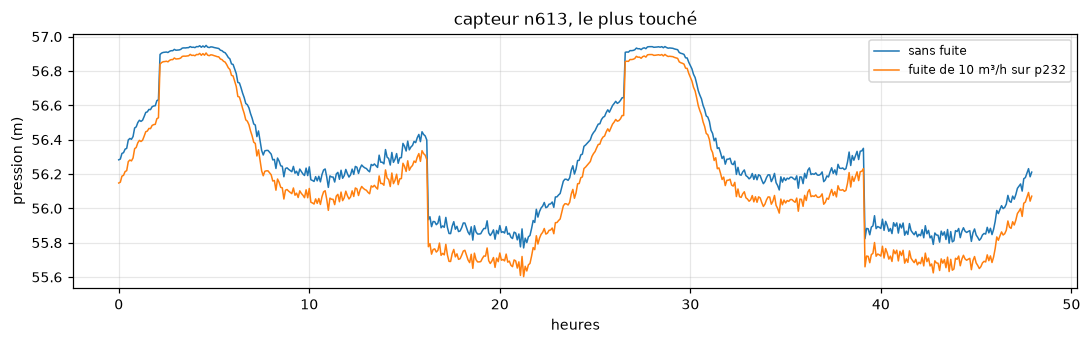

In [8]:
pire = baisse.idxmax()
k = capteurs.index(pire)
h = np.arange(2 * R.PAS_JOUR) / R.PAS_JOUR * 24

fig, ax = plt.subplots()
ax.plot(h, sans_fuite[:len(h), k], lw=1.0, label="sans fuite")
ax.plot(h, avec_fuite[:len(h), k], lw=1.0, label=f"fuite de 10 m³/h sur {conduite}")
ax.set_xlabel("heures"); ax.set_ylabel("pression (m)")
ax.set_title(f"capteur {pire}, le plus touché"); ax.legend(fontsize=8)
fig.tight_layout()

## 4. Est-ce que ça dépasse l'erreur du modèle ?

C'est la seule question qui compte pour un détecteur. Le modèle se trompe déjà tout seul ; une
fuite qui fait moins de bruit que cette erreur est invisible, quel que soit l'algorithme qu'on
mettra derrière.

On compare la baisse à la **dispersion** de l'erreur, pas à son biais : un décalage constant
s'annule dans toute différence, donc il ne gêne pas la détection. C'est la dispersion qui gêne.

In [9]:
lignes = []
for debit in (2.5, 5.0, 10.0, 20.0, 40.0):
    s = simuler(fuites={noeud: R.coefficient_emetteur(debit, p_noeuds[noeud])})
    d = (sans_fuite - s).mean(axis=0)
    lignes.append({"fuite (m³/h)": debit,
                   "baisse médiane (cm)": 100 * np.median(d),
                   "baisse max (cm)": 100 * d.max(),
                   "max ÷ dispersion du modèle": d.max() / erreur["dispersion_m"]})

print(f"dispersion du modèle sur cette fenêtre : {100 * erreur['dispersion_m']:.1f} cm\n")
print(pd.DataFrame(lignes).round(2).to_string(index=False))

dispersion du modèle sur cette fenêtre : 8.3 cm

 fuite (m³/h)  baisse médiane (cm)  baisse max (cm)  max ÷ dispersion du modèle
          2.5                 1.31         2.860000                        0.34
          5.0                 2.64         5.770000                        0.69
         10.0                 5.34        11.820000                        1.42
         20.0                10.92        24.870001                        2.99
         40.0                23.09        54.919998                        6.59


### Lecture

La dispersion du modèle sur cette semaine vaut **8,3 cm**. La dernière colonne dit donc, en un
seul nombre, si la fuite sort du bruit.

* jusqu'à **5 m³/h**, la baisse maximale reste plus petite que l'erreur du modèle : la fuite est
  noyée, et aucun algorithme ne la retrouvera dans ces pressions-là ;
* à **10 m³/h**, elle passe tout juste la tête — 1,4 fois la dispersion ;
* il faut **20 m³/h** pour atteindre un facteur 3, c'est-à-dire pour qu'un seuil simple suffise.

Et 10 m³/h n'est pas une petite fuite : c'est près de 6 % de la consommation de toute la grande
zone. La détection est donc d'abord un problème de rapport signal sur bruit, pas un problème
d'algorithme.

## 5. Une fuite ne se voit pas pareil partout

Tout dépend de ce qu'il y a entre elle et le capteur le plus proche. Reprenons le même débit sur
les quatorze conduites où le jeu de données a placé une fuite en 2018.

In [10]:
lignes = []
for c in R.charger_fuites(ANNEE).columns:
    n = wn.get_link(c).start_node_name
    d = (sans_fuite - simuler(fuites={n: R.coefficient_emetteur(10.0, p_noeuds[n])})).mean(axis=0)
    lignes.append({"conduite": c, "nœud": n, "baisse max (cm)": 100 * d.max(),
                   "capteur le plus touché": capteurs[int(d.argmax())]})

par_endroit = pd.DataFrame(lignes).sort_values("baisse max (cm)", ascending=False)
print("fuite de 10 m³/h, posée tour à tour sur les quatorze conduites :\n")
print(par_endroit.round(2).to_string(index=False))

fuite de 10 m³/h, posée tour à tour sur les quatorze conduites :

conduite nœud  baisse max (cm) capteur le plus touché
    p257 n350        99.510002                     n1
     p31  n40        67.860001                     n4
    p673 n206        26.750000                   n229
    p369 n422        17.360001                   n410
    p158 n232        15.770000                   n644
    p654 n609        14.800000                   n613
    p866 n758        14.550000                   n296
    p183 n299        13.970000                   n752
    p427 n462        13.040000                   n429
    p461 n106        12.860000                   n114
    p628 n590        12.720000                   n613
    p810 n716        12.380000                   n288
    p232 n184        11.820000                   n613
    p538 n531         8.850000                   n506


### Lecture

Le même débit, au même moment, donne **de 8,9 cm à 99,5 cm** selon l'endroit — un facteur onze.

Les deux premières lignes (`p257`, `p31`) sont des conduites d'arrivée : elles portent beaucoup de
débit et un capteur se trouve juste à côté. Les dernières sont en bout de réseau, loin de tout
capteur, et leur fuite se dilue avant d'atteindre quoi que ce soit.

Conséquence pratique pour la suite : un jeu généré avec la fuite **toujours au même endroit**
apprendrait surtout la position de ce capteur-là. Il faut tirer l'emplacement au sort, et garder
l'étiquette.

## 6. Sauvegarder un jeu

De quoi a besoin la suite : les pressions simulées, l'étiquette (où et quand), et le repère sans
fuite. On écrit un `.npz` par scénario, dans `data/generes/` — ignoré par git, ce sont des
données.

In [11]:
sortie = pathlib.Path("..") / "data" / "generes"
sortie.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    sortie / f"semaine1_{conduite}_10m3h.npz",
    pressions=avec_fuite.astype(np.float32),      # (2016, 33)
    reference=sans_fuite.astype(np.float32),      # la même semaine sans fuite
    capteurs=np.array(capteurs),
    conduite=conduite, noeud=noeud, debit_m3h=10.0, debut=DEBUT)

print(f"écrit : {sorted(p.name for p in sortie.glob('*.npz'))}")

écrit : ['semaine1_p232_10m3h.npz']


## Ce qu'il faut retenir

1. **Une fuite, sous EPANET, c'est un émetteur** — `Q = C·√p` posé sur un nœud. `add_leak` de
   WNTR ne fait rien avec ce moteur, et ne le dit pas.
2. **Le débit obtenu peut être inférieur au débit visé**, parce que la fuite fait baisser la
   pression qui l'alimente. On le relit dans la simulation au lieu de le supposer.
3. **La bonne question n'est pas « est-ce que la pression baisse » mais « de combien, comparé à
   l'erreur du modèle ».** Ici : rien jusqu'à 5 m³/h, tout juste à 10, confortable à 20.
4. **L'endroit compte plus que le débit** : à débit égal, un facteur onze entre la meilleure et
   la pire des quatorze conduites.
5. C'est pour cela que les deux carnets précédents comptaient. Chaque centimètre d'erreur retiré
   au modèle est un centimètre de fuite qui devient visible.